**Read Data Set**

In [90]:
# Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [91]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
df = pd.read_excel('/content/drive/MyDrive/kaloriberat.xlsx')
df

,Kalori,Berat
0,530,89
1,300,48
2,358,56
3,510,72
4,302,54
5,300,42
6,387,60
7,527,85
8,415,63
9,512,74


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Kalori  10 non-null     int64
 1   Berat   10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes


In [94]:
df.shape

(10, 2)

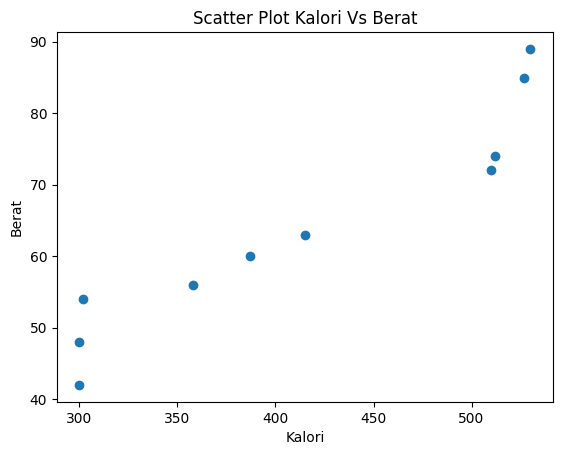

In [95]:
plt.scatter(df['Kalori'], df['Berat'])
plt.xlabel('Kalori')
plt.ylabel('Berat')
plt.title('Scatter Plot Kalori Vs Berat')
plt.show()

**Independent dan Dependent Variable**

In [96]:
x = df.iloc[:,[0]].values
y = df.iloc[:,[1]].values

In [97]:
x

array([[530],
       [300],
       [358],
       [510],
       [302],
       [300],
       [387],
       [527],
       [415],
       [512]])

In [98]:
y

array([[89],
       [48],
       [56],
       [72],
       [54],
       [42],
       [60],
       [85],
       [63],
       [74]])

**Split Train Test**

In [99]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [100]:
x_test

array([[358],
       [415]])

In [101]:
x_train

array([[302],
       [512],
       [300],
       [387],
       [527],
       [510],
       [530],
       [300]])

In [102]:
y_test

array([[56],
       [63]])

In [103]:
y_train

array([[54],
       [74],
       [48],
       [60],
       [85],
       [72],
       [89],
       [42]])

**Model Regres**i

In [104]:
from sklearn.linear_model import LinearRegression
regresi = LinearRegression()
regresi.fit(x_train,y_train)

LinearRegression()

**Visualisasi Data dan Garis Regresi**

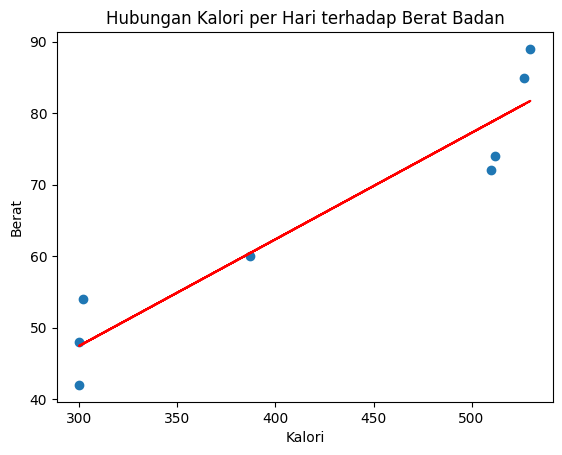

In [105]:
# Sebaran data train
plt.scatter(x_train,y_train)

# Garis regresi
plt.plot(x_train,regresi.predict(x_train),color='red')
plt.xlabel('Kalori')
plt.ylabel('Berat')
plt.title('Hubungan Kalori per Hari terhadap Berat Badan')
plt.show()

**Testing model**

In [106]:
y_prediksi = regresi.predict(x_test)
print(y_prediksi)

[[56.11809147]
 [64.6064849 ]]


**Test Data Baru**

In [107]:
# Jika kalori 600 per hari maka berat badanya berapa..?
data_baru = [[600]]
prediksi_baru = regresi.predict(data_baru)
print(prediksi_baru)

[[92.15653376]]


**Analisis Korelasi**

In [108]:
df.corr(method='pearson')

,Kalori,Berat
Kalori,1.000000,0.950093
Berat,0.950093,1.000000


**Analisis Mean Absolute Error (MAE)**

In [109]:
print(f"(MAE): {mae:.4f}")

(MAE): 0.8623


Nilai MAE sebesar 0.8623 berarti bahwa, secara rata-rata, prediksi berat badan yang dihasilkan oleh model regresi menyimpang sekitar 0.8623 kg dari berat badan sebenarnya di set data pengujian. Semakin kecil nilai MAE, semakin akurat model dalam membuat prediksi.

**Analisis Mean Squared Error (MSE) dan Root Mean Squared Error (RMSE)**

In [110]:
print(f"(MSE): {mse:.4f}")
print(f"(RMSE): {rmse:.4f}")

(MSE): 1.2974
(RMSE): 1.1390


Nilai RMSE sebesar 1.1390 berarti bahwa, rata-rata prediksi berat badan yang dihasilkan oleh model regresi menyimpang sekitar 1.1390 kg dari berat badan sebenarnya. Semakin kecil nilai RMSE, semakin baik model dalam membuat prediksi.

**Analisis R-Squared (Koefisien Determinasi)**

In [111]:
print(f"(R2) value: {r2:.4f}")

(R2) value: 0.8941


Nilai R2 sebesar 0.8941 (atau 89.41%) berarti bahwa sekitar 89.41% dari variasi dalam 'Berat' dapat dijelaskan oleh 'Kalori' melalui model regresi linear yang dibuat. Ini adalah nilai yang cukup tinggi, menunjukkan bahwa model ini cukup baik dalam memprediksi berat badan berdasarkan asupan kalori.